In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../")))

import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import load_cifar10
from src.data.preprocess import prepare_colourization_data

In [2]:
(x_train, y_train), (x_test, y_test) = load_cifar10()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Extracting CIFAR-10


c:\Users\ASUS\Desktop\UofT\Winter 2026\MIE1517 Intro to Deep Learning\A3\GitHub\Project\src\data\loader.py:40: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f, encoding="bytes")


Train shape: (50000, 3, 32, 32)
Test shape: (10000, 3, 32, 32)


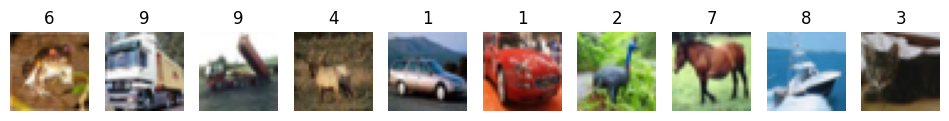

In [3]:
def show_samples(images, labels, num=10):
    plt.figure(figsize=(12, 3))
    for i in range(num):
        plt.subplot(1, num, i+1)
        img = np.transpose(images[i], (1, 2, 0))
        plt.imshow(img)
        plt.axis("off")
        plt.title(labels[i])
    plt.show()

show_samples(x_train, y_train)

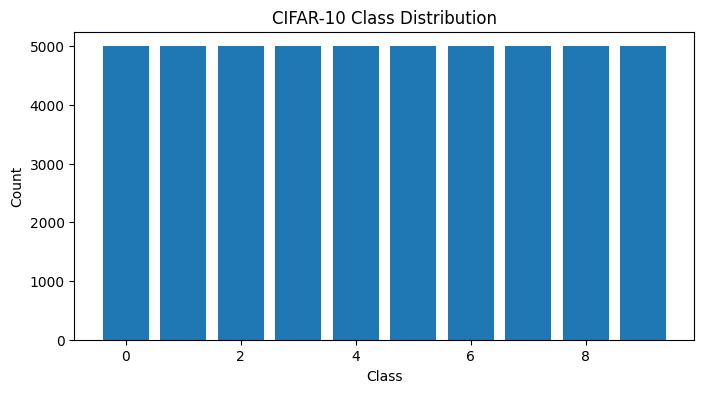

In [4]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("CIFAR-10 Class Distribution")
plt.show()

In [5]:
train_rgb, train_grey = prepare_colourization_data(x_train, y_train)

print("Horse RGB shape:", train_rgb.shape)
print("Horse Grey shape:", train_grey.shape)

Horse RGB shape: (5000, 3, 32, 32)
Horse Grey shape: (5000, 1, 32, 32)


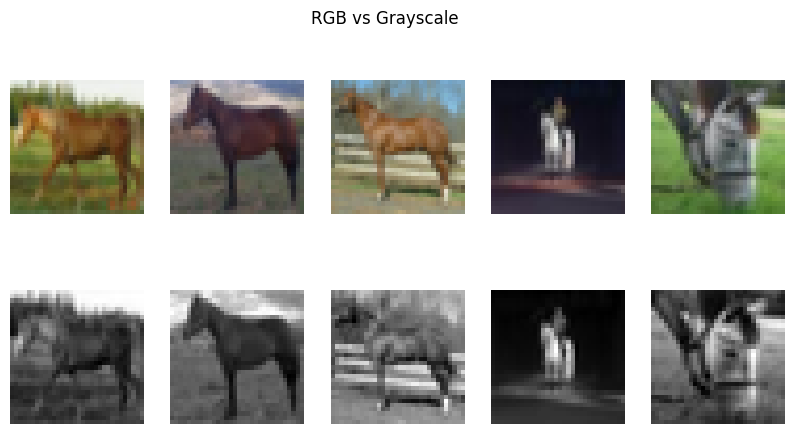

In [6]:
plt.figure(figsize=(10, 5))

for i in range(5):
    # RGB
    plt.subplot(2, 5, i+1)
    plt.imshow(np.transpose(train_rgb[i], (1, 2, 0)))
    plt.axis("off")

    # Grayscale
    plt.subplot(2, 5, i+6)
    plt.imshow(train_grey[i][0], cmap="gray")
    plt.axis("off")

plt.suptitle("RGB vs Grayscale")
plt.show()

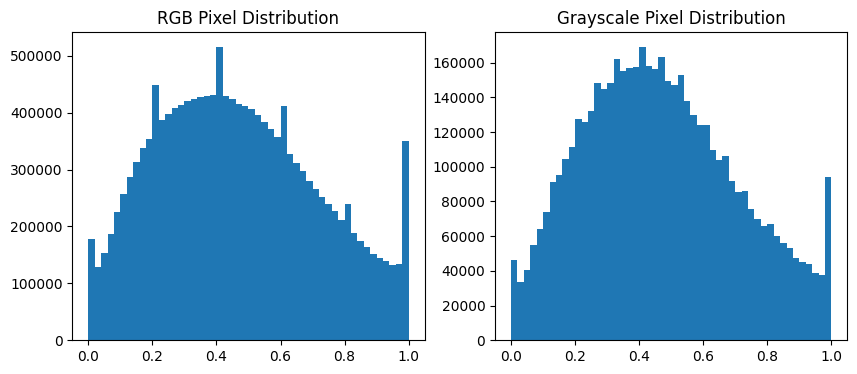

In [7]:
rgb_pixels = train_rgb.flatten()
grey_pixels = train_grey.flatten()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(rgb_pixels, bins=50)
plt.title("RGB Pixel Distribution")

plt.subplot(1, 2, 2)
plt.hist(grey_pixels, bins=50)
plt.title("Grayscale Pixel Distribution")

plt.show()

- CIFAR-10 images are small (32x32) with 3 color channels
- Classes are balanced across dataset
- After filtering, only horse images are used for colorization
- Grayscale images lose color information but preserve structure
- Pixel values are normalized to [0, 1]